## Chapter 12 - Applied

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

In [2]:
# New imports
from sklearn.cluster import (
    KMeans ,
    AgglomerativeClustering 
)
from scipy.cluster.hierarchy import (
    dendrogram,
    cut_tree
)
from ISLP.cluster import compute_linkage
from sklearn.metrics import pairwise_distances

### Question 7

In [3]:
# Get arrests data from R
arrests = get_rdataset('USArrests').data
arrests.columns = [x.lower() for x in arrests.columns]
arrests.head()

,murder,assault,urbanpop,rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [4]:
# Scale data
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(arrests)

In [5]:
# Computing correlation between observations
corr_matrix = np.corrcoef(X_scaled.T)
dist_corr_matrix = 1 - corr_matrix

# Compute Euclidean distance & square it
dist_euclidean_sq = pairwise_distances(X_scaled.T, metric='euclidean')**2

In [6]:
# Check squared Euclidean distance
dist_euclidean_sq

array([[ 0.        , 19.81266883, 93.04273783, 43.6421167 ],
       [19.81266883,  0.        , 74.1128298 , 33.47587703],
       [93.04273783, 74.1128298 ,  0.        , 58.86587644],
       [43.6421167 , 33.47587703, 58.86587644,  0.        ]])

In [7]:
# Check correlation 
dist_corr_matrix

array([[2.22044605e-16, 1.98126688e-01, 9.30427378e-01, 4.36421167e-01],
       [1.98126688e-01, 0.00000000e+00, 7.41128298e-01, 3.34758770e-01],
       [9.30427378e-01, 7.41128298e-01, 2.22044605e-16, 5.88658764e-01],
       [4.36421167e-01, 3.34758770e-01, 5.88658764e-01, 0.00000000e+00]])

In [8]:
with np.errstate(divide='ignore', invalid='ignore'):
    print(dist_corr_matrix / dist_euclidean_sq)
    

[[ inf 0.01 0.01 0.01]
 [0.01  nan 0.01 0.01]
 [0.01 0.01  inf 0.01]
 [0.01 0.01 0.01  nan]]


After examining the Euclidean distance matrix and the correlation-based matrix, it becomes evident that the two are proportional to each other by a factor of 100. This is confirmed by computing the ration of the two matrices, which outputs same values of 0.01 with the exception of the diagonal (0s).

---

### Question 8

#### 8a)

In [9]:
# Create & fit a pca method
pca = PCA()
pca.fit(X_scaled)

# Show PVE
pca.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

#### 8b)

In [10]:
# Get PCAs & compute PVE
pve_list = []
for component_ in pca.components_:
    pve = np.sum(np.matmul(component_, X_scaled.T)**2) / np.sum(X_scaled**2)
    pve_list.append(pve)

# Show PVE
np.asarray(pve_list)

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

---

### Question 9

#### 9a)

In [11]:
# Complete linkage (maximum value/distance)
HClust = AgglomerativeClustering
hc_comp = HClust(
    distance_threshold=0,
    n_clusters=None,
    linkage='complete'
)
hc_comp.fit(arrests)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

#### 9b)

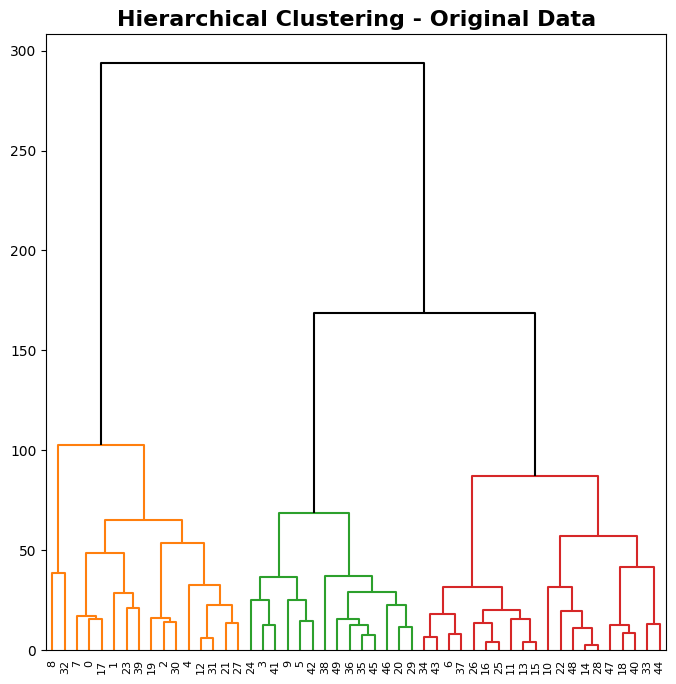

In [12]:
# Compute linkage-matrix & plot the dendrogram
cargs = {
    'color_threshold': -np.inf,
    'above_threshold_color': 'black'
}
linkage_comp = compute_linkage(hc_comp)

# Color branches below a threshold
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_comp,
    ax=ax,
    color_threshold=150,
    above_threshold_color='black'
)

# Add title
title_args = {
    'fontsize': 16,
    'fontweight': 'bold'
}
axis_args = {
    'fontsize': 14,
    'fontweight': 'bold'
}
plt.title('Hierarchical Clustering - Original Data', **title_args);

In [13]:
# Get the cluster labels associated with a threshold
cut_tree(linkage_comp, n_clusters=3).T

array([[0, 0, 0, 1, 0, 1, 2, 0, 0, 1, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 1, 0,
        2, 0, 1, 2, 2, 0, 2, 1, 0, 0, 0, 2, 2, 1, 1, 2, 1, 0, 2, 1, 1, 2,
        2, 1, 1, 2, 2, 1]])

In [14]:
# Create a dataframe shows states & clusters
hcluster_regular = pd.DataFrame(
    cut_tree(linkage_comp, n_clusters=3), 
    index=arrests.index, 
    columns=['Cluster']
).rename_axis('State')
hcluster_regular

,Cluster
State,
Alabama,0
Alaska,0
Arizona,0
Arkansas,1
California,0
Colorado,1
Connecticut,2
Delaware,0
Florida,0


#### 9c)

In [15]:
# Complete linkage (maximum value/distance)
HClust = AgglomerativeClustering
hc_comp = HClust(
    distance_threshold=0,
    n_clusters=None,
    linkage='complete'
)
hc_comp.fit(X_scaled)

AgglomerativeClustering(distance_threshold=0, linkage='complete',
                        n_clusters=None)

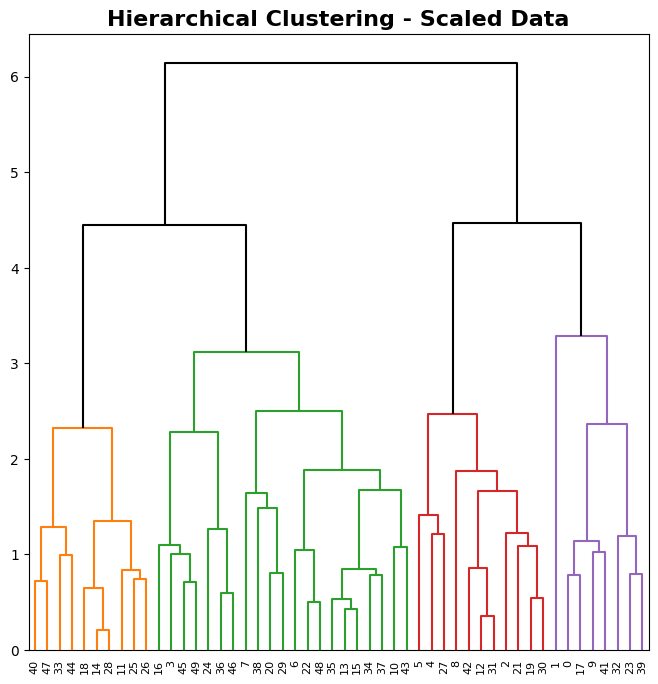

In [16]:
# Compute linkage-matrix & plot the dendrogram
cargs = {
    'color_threshold': -np.inf,
    'above_threshold_color': 'black'
}
linkage_comp = compute_linkage(hc_comp)

# Color branches below a threshold
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_comp,
    ax=ax,
    color_threshold=4,
    above_threshold_color='black'
)
plt.title('Hierarchical Clustering - Scaled Data', **title_args);

#### 9d)

Visually, clustering appears more balanced after scaling the data. Without scaling, the algorithm tends to split the data into 3 distinct and dominant clusters, likely drinv by variables with larger scales. After scaling, a 4 cluster solution becomes more natural, and the overall separation between states appears more meaningful and balanced.

Scaling is essential before computing dissimilarities because the original features are measured on different scales. For instance, the 'murder' variable is measured as incidents per 100,000 people, while 'urbanpop' is expressed as a percentage. Without scaling, variables with larger numeric ranges dominate the distance calculations, leading to biased clustering results.

---

### Question 10

#### 10a)

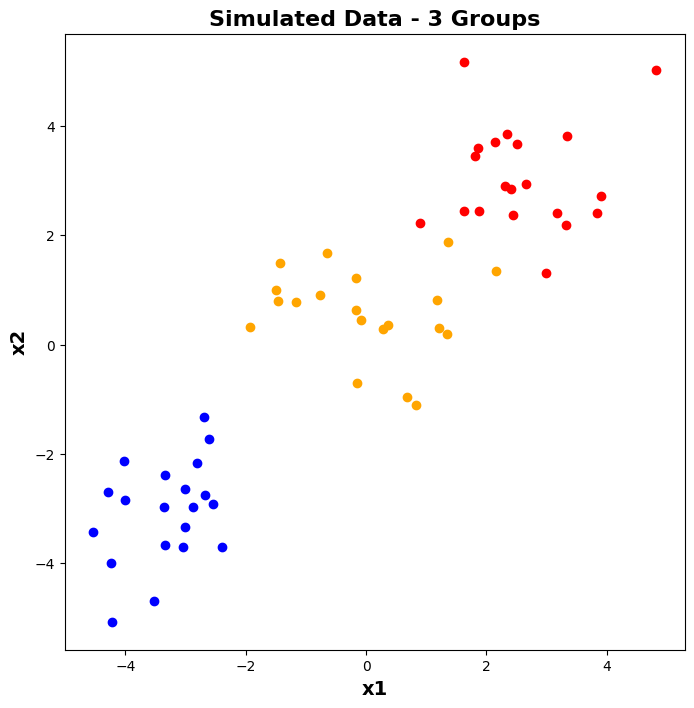

In [17]:
# Generate data
rng = np.random.default_rng(1)
X1 = rng.normal(loc=3, size=(20, 50))
X2 = rng.normal(loc=-3, size=(20, 50))
X3 = rng.normal(size=(20, 50))
X = np.concatenate((X1, X2, X3), axis=0)

# Plot data
plt.figure(figsize=(8, 8))
plt.scatter(X[:20, 0], X[:20, 1], c='red', label='class1')
plt.scatter(X[20:40, 0], X[20:40, 1], c='blue', label='class2')
plt.scatter(X[40:, 0], X[40:, 1], c='orange', label='class3')
plt.title('Simulated Data - 3 Groups', **title_args)
plt.xlabel('x1', **axis_args)
plt.ylabel('x2', **axis_args);


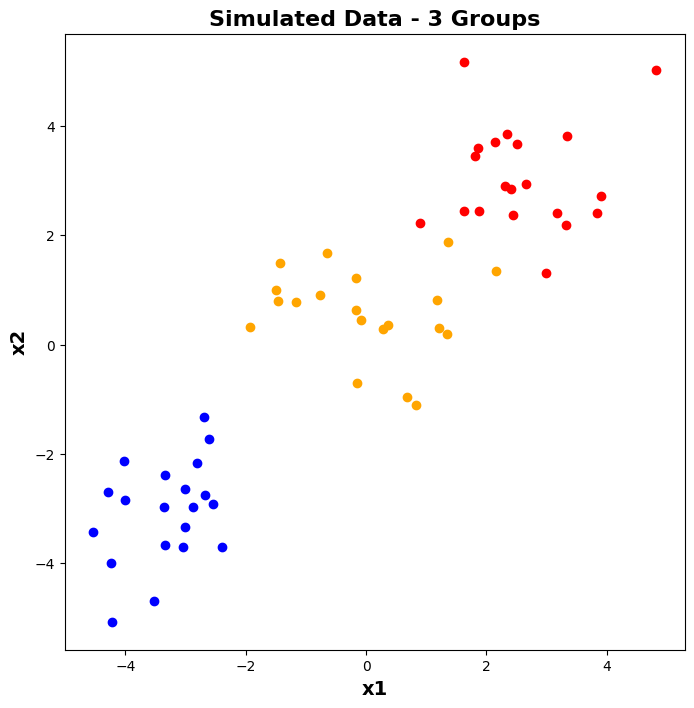

In [18]:
# Generate data
rng = np.random.default_rng(1)
X1 = rng.normal(loc=3, size=(20, 50))
X2 = rng.normal(loc=-3, size=(20, 50))
X3 = rng.normal(size=(20, 50))
X = np.concatenate((X1, X2, X3), axis=0)

# Plot data
plt.figure(figsize=(8, 8))
plt.scatter(X[:20, 0], X[:20, 1], c='red', label='class1')
plt.scatter(X[20:40, 0], X[20:40, 1], c='blue', label='class2')
plt.scatter(X[40:, 0], X[40:, 1], c='orange', label='class3')
plt.title('Simulated Data - 3 Groups', **title_args)
plt.xlabel('x1', **axis_args)
plt.ylabel('x2', **axis_args);


#### 10b)

In [19]:
# Label the classes
y = np.array([0]*20 + [1]*20 + [2]*20)

In [20]:
# Create & fit a pca method
pca = PCA()
pca.fit(X)

# Compute PCA scores
scores = pca.transform(X)

# Show PVE
pca.explained_variance_ratio_

array([8.62149315e-01, 1.04699005e-02, 8.57717064e-03, 8.09918117e-03,
       7.70271493e-03, 7.03743902e-03, 6.32291183e-03, 6.23103580e-03,
       6.03538485e-03, 5.74617990e-03, 4.88795690e-03, 4.71774499e-03,
       4.62811122e-03, 4.47759902e-03, 4.17333969e-03, 3.94036927e-03,
       3.60419970e-03, 3.31516203e-03, 3.12170483e-03, 2.85075107e-03,
       2.67152450e-03, 2.52777008e-03, 2.45554169e-03, 2.29855185e-03,
       2.11367354e-03, 2.07326048e-03, 1.90533677e-03, 1.84951232e-03,
       1.66297771e-03, 1.44012346e-03, 1.25587851e-03, 1.18098558e-03,
       1.06000179e-03, 1.03183649e-03, 9.65628153e-04, 8.36477642e-04,
       7.58779152e-04, 7.12761335e-04, 5.54935610e-04, 5.26917013e-04,
       3.90182694e-04, 3.86144583e-04, 3.28849419e-04, 2.57600183e-04,
       2.24869705e-04, 1.63724084e-04, 1.16751010e-04, 8.21483748e-05,
       5.99732248e-05, 1.91102327e-05])

PCA captures approximately 88% of the total variance in the data within the first 2 principal components. This indicates that most of the data's structure can be effectively represented in a two-dimensional space, regardless of the 60 variables in our dataset.

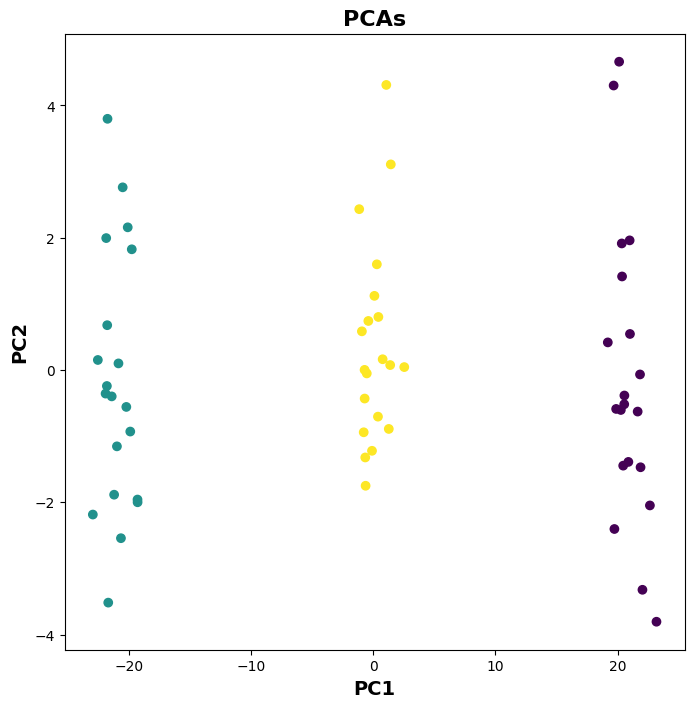

In [21]:
# Biplot visualization
i, j = 0, 1 # which component
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax.scatter(scores[:, 0], scores[:, 1], c=y)
ax.set_title('PCAs', **title_args)
ax.set_xlabel('PC%d' % (i+1), **axis_args)
ax.set_ylabel('PC%d' % (j+1), **axis_args);

#### 10c)

In [22]:
# Perform K-Meas with K=3
kmeans_k3 = KMeans(n_clusters=3, random_state=1, n_init=20).fit(X)

In [23]:
# Check labels
pd.crosstab(
    index=kmeans_k3.labels_,
    columns=y,
    rownames=['kmeans_class'],
    colnames=['y']
)

y,0,1,2
kmeans_class,,,
0,0,0,20
1,20,0,0
2,0,20,0


Since K-means assigns cluster labels arbitrarily, the numeric labels it produces may not match the true class labels. However, the algorithm has successfully grouped all observations according to their true classes, just with different numeric labels. For instance, there are 20 observations in true class 0 that K-means assigned to cluster 1. This is evident in the first column labeled '# 0', where all entries belong to true class 0, but K-means grouped them under cluster 1.

#### 10d)

In [24]:
# Perform K-Means with K=2
kmeans_k2 = KMeans(n_clusters=2, random_state=1, n_init=20).fit(X)

In [25]:
# Check labels
pd.crosstab(
    index=kmeans_k2.labels_,
    columns=y,
    rownames=['kmeans_class'],
    colnames=['y']
)

y,0,1,2
kmeans_class,,,
0,20,0,20
1,0,20,0


With only 2 cluster options, K-means correctly identifies all observations from true class 1. However, it merges the remaining 2 classes (0 and 2) into a single cluster, labeled as cluster 0.

#### 10e)

In [26]:
# Perform K-Means with K=4
kmeans_k4 = KMeans(n_clusters=4, random_state=1, n_init=20).fit(X)

In [27]:
# Check labels
pd.crosstab(
    index=kmeans_k4.labels_,
    columns=y,
    rownames=['kmeans_class'],
    colnames=['y']
)

y,0,1,2
kmeans_class,,,
0,4,0,0
1,0,20,0
2,16,0,0
3,0,0,20


When clustering the data into 4 groups (K=4), one moe than the true number of classes, K-means correctly identifies 2 of he original classes. However it splits the remaining class into 2 separate clusters.

#### 10f)

In [28]:
# Perform K-means over first 2 PCs (principal components)
kmeans_pca_k3 = KMeans(n_clusters=3, random_state=1, n_init=20).fit(scores[:, [0,1]])

In [29]:
# Check labels
pd.crosstab(
    index=kmeans_pca_k3.labels_,
    columns=y,
    rownames=['kmeans_class'],
    colnames=['y']
)

y,0,1,2
kmeans_class,,,
0,0,20,0
1,20,0,0
2,0,0,20


As explained before, K-means assigns cluster labels arbitrarily. So the algorithm has successfully grouped all observations according to their true classes, just with different numeric labels.

#### 10g)

In [30]:
# Scale the data
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

In [31]:
# Perform K-means clustering
kmeans_scaled_k3 = KMeans(n_clusters=3, random_state=1, n_init=20).fit(X_scaled)

In [32]:
# Compare labels
pd.crosstab(
    index=kmeans_scaled_k3.labels_,
    columns=y,
    rownames=['kmeans_class'],
    colnames='y'
)

y,0,1,2
kmeans_class,,,
0,0,0,20
1,20,0,0
2,0,20,0


K-means with 3 clusters (K=3) applied to the scaled data successfully separates the data into 3 distinct group, each corresponding to one of the original classes.

---

### Question 11

In [33]:
# Create a function to perform low rank approximation
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:, :M] * D[None, :M]
    return L.dot(V[:M])

In [34]:
# Create a function to perform matrix completion
def matrix_completion(
        X, 
        rank_func=low_rank,
        M=1,
        threshold=1e-7, 
        max_iterations=30,
        verbose=True
    ):

    # Fill missing values with column means
    Xhat = X.copy()
    col_means = np.nanmean(Xhat, axis=0)
    inds = np.where(np.isnan(Xhat))
    Xhat[inds] = np.take(col_means, inds[1])

    # Initiate variables
    rel_err = 1
    count = 0
    missing = np.isnan(X)
    mss_old = np.mean(Xhat[~missing]**2)
    mss_0 = np.mean(X[~missing]**2)

    # Iterate
    while (rel_err > threshold) & (count < max_iterations):
        count += 1

        # Step 2(a)
        Xapp = low_rank(Xhat, M=M)
        # Step 2(b)
        Xhat[missing] = Xapp[missing]
        # Step 2(c)
        mss = np.mean(((X - Xapp)[~missing])**2)
        rel_err = (mss_old - mss) / mss_0
        mss_old = mss

        # Print progress
        if verbose:
            text = f"Iteration: {count}, MSS: {mss: .3f}, Rel.Err: {rel_err:.2e}"
            print(text)
    return Xhat

In [35]:
# Load & inspect 'Boston' dataset
boston = pd.read_csv('data/Boston.csv')
boston = boston.iloc[:, 1:]
print(boston.info())

# Create scaler & transform dataset
scaler = StandardScaler(with_mean=True, with_std=True)
boston_scaled = scaler.fit_transform(boston)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB
None


In [36]:
# Check first observations
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [37]:
# Inspect correlation between features/variables
boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


In [38]:
# Inspect correlation between scaled features/variables
pd.DataFrame(np.corrcoef(boston_scaled, rowvar=False))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
1,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
2,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
3,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
4,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
5,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
6,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
7,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
8,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
9,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


We observe substantial correlation between some features/variables (e.g. above 0.7), which could pose issues for processes that require full-rank matrix. When features are exact linear combinations of others (perfect multicollinearity), the matrix becoms rank-deficient. Even when correlations are not perfect, very high correlation can lead to near multicollinearity, causing numerical instability and be treated as rank deficiency.

##### <b>Non-Scaled Data</b>

In [39]:
# Ensure 'boston' is an array
boston_array = np.asarray(boston)

# Initialize a dataframe to store the results
columns = ['repetition', 'missing', 'm', 'mss']
results = pd.DataFrame(columns=columns)

# Perform the experiment 20x
np.random.seed (1)
for n in range(1, 21):

    # Create missing data from 5% to 30%
    for i in range(5, 31, 5):            
        # Number of observations to omit
        n_omit = int(len(boston_array) * (i/100))

        # Select rows and columns
        row_idx = np.random.choice(
            np.arange(boston_array.shape[0]),
            n_omit,
            replace=False
        )
        col_idx = np.random.choice(
            np.arange(boston_array.shape[1]),
            n_omit,
            replace=True
        )

        # Creat a dataframe with missing values
        Xna = boston_array.copy()
        Xna = np.asarray(Xna)
        Xna[row_idx, col_idx] = np.nan
        missing = np.isnan(Xna)

        # Perform matrix completion over a range of Ms
        for m in range(1, 9):
            Xhat = matrix_completion(X=Xna, M=m, verbose=False)
            mss = np.mean(((boston_array - Xhat)[missing])**2)

            # Update dataframe
            results.loc[len(results)] = (n, i, m, mss)

In [40]:
# Group results by their average
columns = ['missing', 'm']
results_agg = results.groupby(columns).agg({
    'mss': 'mean'
}).reset_index()

# Sort & show results
results_agg.sort_values(by='mss', ascending=True)

,missing,m,mss
0,5.0,1.0,1485.509968
24,20.0,1.0,1498.381809
40,30.0,1.0,1562.772023
2,5.0,3.0,1771.779806
26,20.0,3.0,1773.598371
16,15.0,1.0,1783.478508
27,20.0,4.0,1792.786333
32,25.0,1.0,1813.137547
28,20.0,5.0,1838.374374
3,5.0,4.0,1878.222635


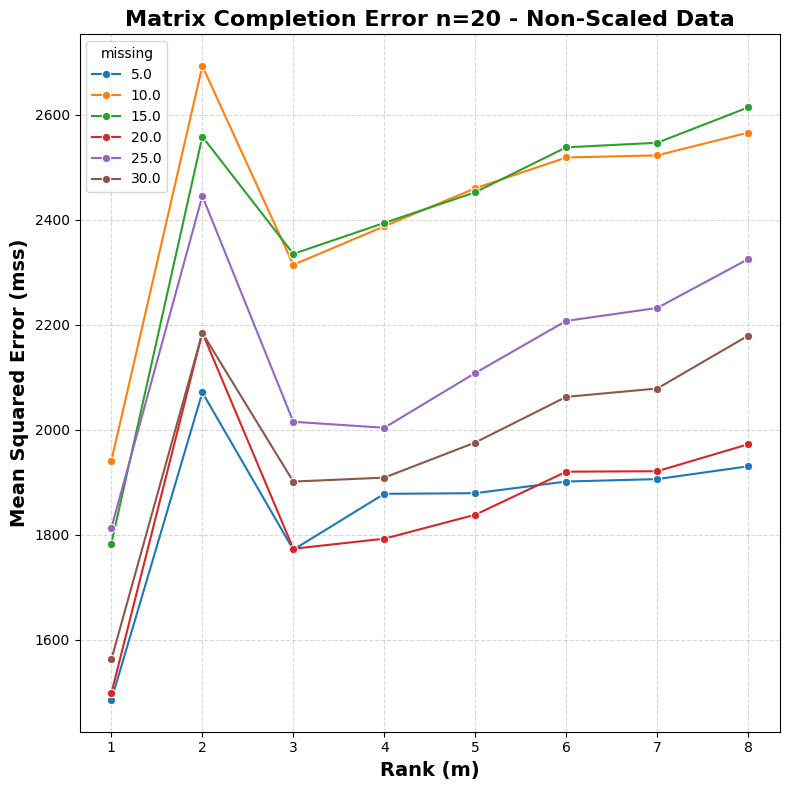

In [41]:
# Plot results
palette = sns.color_palette("tab10", n_colors=results_agg['missing'].nunique())
plt.figure(figsize=(8, 8))
sns.lineplot(
    data=results_agg, 
    x='m', 
    y='mss', 
    hue='missing', 
    marker='o',
    palette=palette
)
plt.xlabel('Rank (m)', **axis_args)
plt.ylabel('Mean Squared Error (mss)', **axis_args)
plt.title('Matrix Completion Error n=20 - Non-Scaled Data', **title_args)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

It is clear that, regardless of the percentage of missing data, the value of 'm' (rank used in the matrix completion) that minimizes the mean squared error ('mss') is consistently 1. Interestingly, 'm'=2 tends to produce the highest error, while 'm'=3 usually follows as the next best performer after 'm'=1.


Although the 5% missing data condition yields the lowest 'mss', the trend is not consistently ascending. For instance, the 10% missing data does not produce the second-lowest 'mss', but 20% does. A larger number of repetitions could help smooth out the variability and provide more reliable estimates of reconstruction error across different missingness levels.


In [42]:
# Ensure 'boston' is an array
boston_array = np.asarray(boston)

# Initialize a dataframe to store the results
columns = ['repetition', 'missing', 'm', 'mss']
results = pd.DataFrame(columns=columns)

# Perform the experiment 10x
np.random.seed (1)
for n in range(1, 101):

    # Create missing data from 5% to 30%
    for i in range(5, 31, 5):            
        # Number of observations to omit
        n_omit = int(len(boston_array) * (i/100))

        # Select rows and columns
        row_idx = np.random.choice(
            np.arange(boston_array.shape[0]),
            n_omit,
            replace=False
        )
        col_idx = np.random.choice(
            np.arange(boston_array.shape[1]),
            n_omit,
            replace=True
        )

        # Creat a dataframe with missing values
        Xna = boston_array.copy()
        Xna = np.asarray(Xna)
        Xna[row_idx, col_idx] = np.nan
        missing = np.isnan(Xna)

        # Perform matrix completion over a range of Ms
        for m in range(1, 9):
            Xhat = matrix_completion(X=Xna, M=m, verbose=False)
            mss = np.mean(((boston_array - Xhat)[missing])**2)

            # Update dataframe
            results.loc[len(results)] = (n, i, m, mss)

In [43]:
# Group results by their average
columns = ['missing', 'm']
results_agg = results.groupby(columns).agg({
    'mss': 'mean'
}).reset_index()

# Sort & show results
results_agg.sort_values(by='mss', ascending=True)

,missing,m,mss
24,20.0,1.0,1589.325535
40,30.0,1.0,1633.121508
32,25.0,1.0,1647.597588
8,10.0,1.0,1727.150047
0,5.0,1.0,1779.135876
16,15.0,1.0,1799.198109
42,30.0,3.0,1832.026449
43,30.0,4.0,1836.571927
44,30.0,5.0,1901.635669
34,25.0,3.0,1906.335175


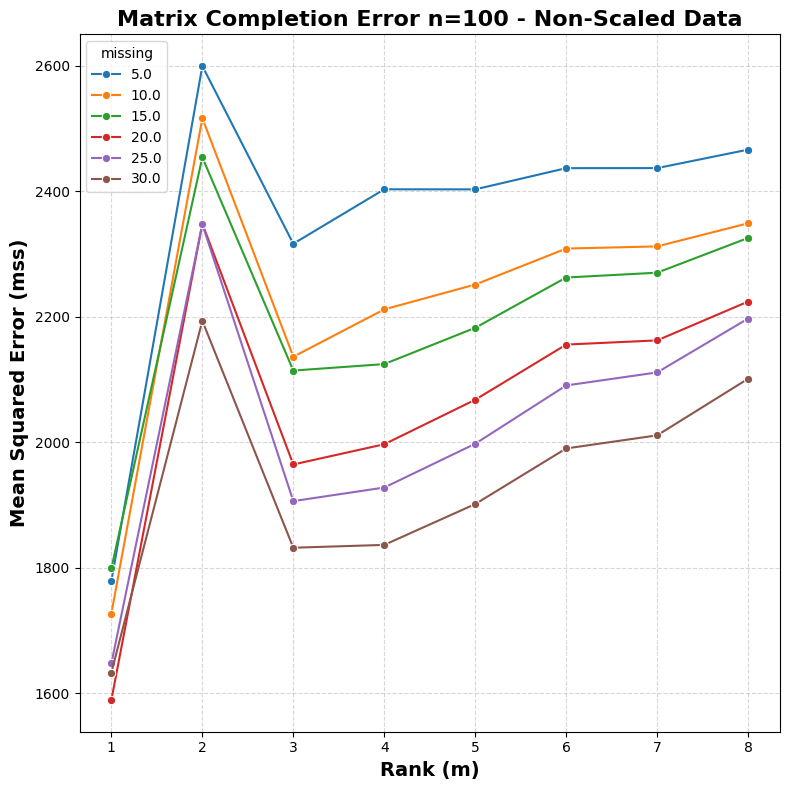

In [44]:
# Plot results
palette = sns.color_palette("tab10", n_colors=results_agg['missing'].nunique())
plt.figure(figsize=(8, 8))
sns.lineplot(
    data=results_agg, 
    x='m', 
    y='mss', 
    hue='missing', 
    marker='o',
    palette=palette
)
plt.xlabel('Rank (m)', **axis_args)
plt.ylabel('Mean Squared Error (mss)', **axis_args)
plt.title('Matrix Completion Error n=100 - Non-Scaled Data', **title_args)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

As expected, increasing the number of repetitions to 100 leads to more stable results of the mean squared error ('mss'), with average values between 1600 to 1800. Regardless of the proportion of missing data, 5% to 30%, the average 'mss' remains relatively consistent.

It is important to note, that while the 'mss' remains similar, the total error will increase with more missing entries. But the matrix completion algorithm maintains similar reconstruction accuracy on a per-value basis, even as the amount of missing data grows.

The results consistengly show that using a low-rank approximation with 'm'=1 results on the lowest 'mss'.

##### <b>Scaled Data</b>

In [45]:
# Ensure 'boston' is an array
boston_array = np.asarray(boston_scaled)

# Initialize a dataframe to store the results
columns = ['repetition', 'missing', 'm', 'mss']
results = pd.DataFrame(columns=columns)

# Perform the experiment 20x
np.random.seed (1)
for n in range(1, 21):

    # Create missing data from 5% to 30%
    for i in range(5, 31, 5):            
        # Number of observations to omit
        n_omit = int(len(boston_array) * (i/100))

        # Select rows and columns
        row_idx = np.random.choice(
            np.arange(boston_array.shape[0]),
            n_omit,
            replace=False
        )
        col_idx = np.random.choice(
            np.arange(boston_array.shape[1]),
            n_omit,
            replace=True
        )

        # Creat a dataframe with missing values
        Xna = boston_array.copy()
        Xna = np.asarray(Xna)
        Xna[row_idx, col_idx] = np.nan
        missing = np.isnan(Xna)

        # Perform matrix completion over a range of Ms
        for m in range(1, 9):
            Xhat = matrix_completion(X=Xna, M=m, verbose=False)
            mss = np.mean(((boston_array - Xhat)[missing])**2)

            # Update dataframe
            results.loc[len(results)] = (n, i, m, mss)

In [46]:
# Group results by their average
columns = ['missing', 'm']
results_agg = results.groupby(columns).agg({
    'mss': 'mean'
}).reset_index()

# Sort & show results
results_agg.sort_values(by='mss', ascending=True)

,missing,m,mss
2,5.0,3.0,0.430357
26,20.0,3.0,0.493394
18,15.0,3.0,0.499435
34,25.0,3.0,0.512152
1,5.0,2.0,0.516928
42,30.0,3.0,0.517551
25,20.0,2.0,0.530934
10,10.0,3.0,0.536005
17,15.0,2.0,0.546744
41,30.0,2.0,0.562417


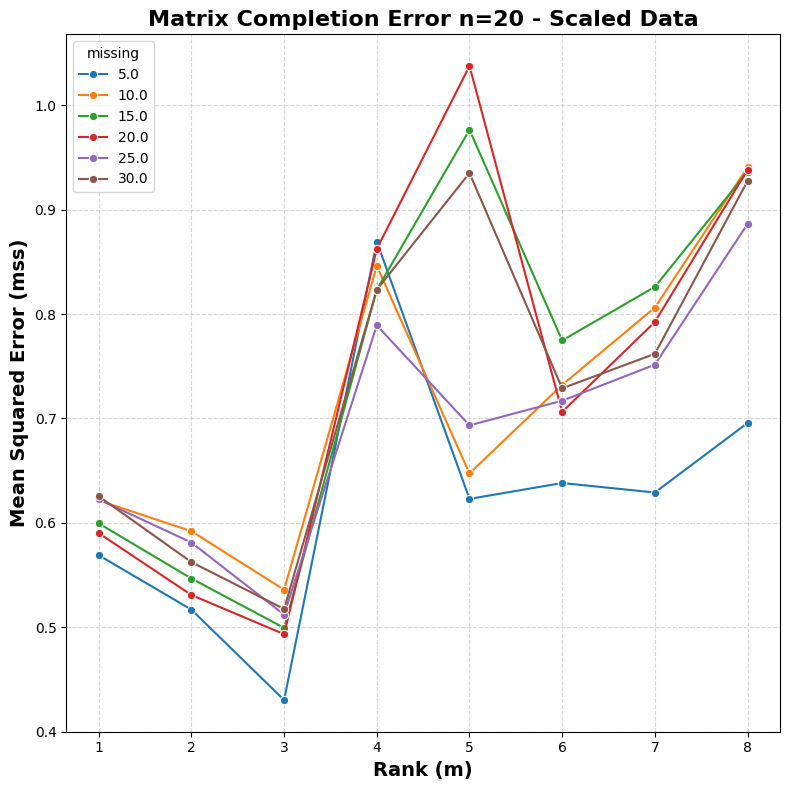

In [47]:
# Plot results
palette = sns.color_palette("tab10", n_colors=results_agg['missing'].nunique())
plt.figure(figsize=(8, 8))
sns.lineplot(
    data=results_agg, 
    x='m', 
    y='mss', 
    hue='missing', 
    marker='o',
    palette=palette
)
plt.xlabel('Rank (m)', **axis_args)
plt.ylabel('Mean Squared Error (mss)', **axis_args)
plt.title('Matrix Completion Error n=20 - Scaled Data', **title_args)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [48]:
# Ensure 'boston' is an array
boston_array = np.asarray(boston_scaled)

# Initialize a dataframe to store the results
columns = ['repetition', 'missing', 'm', 'mss']
results = pd.DataFrame(columns=columns)

# Perform the experiment 10x
np.random.seed (1)
for n in range(1, 101):

    # Create missing data from 5% to 30%
    for i in range(5, 31, 5):            
        # Number of observations to omit
        n_omit = int(len(boston_array) * (i/100))

        # Select rows and columns
        row_idx = np.random.choice(
            np.arange(boston_array.shape[0]),
            n_omit,
            replace=False
        )
        col_idx = np.random.choice(
            np.arange(boston_array.shape[1]),
            n_omit,
            replace=True
        )

        # Creat a dataframe with missing values
        Xna = boston_array.copy()
        Xna = np.asarray(Xna)
        Xna[row_idx, col_idx] = np.nan
        missing = np.isnan(Xna)

        # Perform matrix completion over a range of Ms
        for m in range(1, 9):
            Xhat = matrix_completion(X=Xna, M=m, verbose=False)
            mss = np.mean(((boston_array - Xhat)[missing])**2)

            # Update dataframe
            results.loc[len(results)] = (n, i, m, mss)

In [49]:
# Group results by their average
columns = ['missing', 'm']
results_agg = results.groupby(columns).agg({
    'mss': 'mean'
}).reset_index()

# Sort & show results
results_agg.sort_values(by='mss', ascending=True)

,missing,m,mss
18,15.0,3.0,0.468583
2,5.0,3.0,0.481678
26,20.0,3.0,0.488141
34,25.0,3.0,0.490028
42,30.0,3.0,0.509283
10,10.0,3.0,0.514601
17,15.0,2.0,0.518746
25,20.0,2.0,0.537170
33,25.0,2.0,0.539722
1,5.0,2.0,0.550525


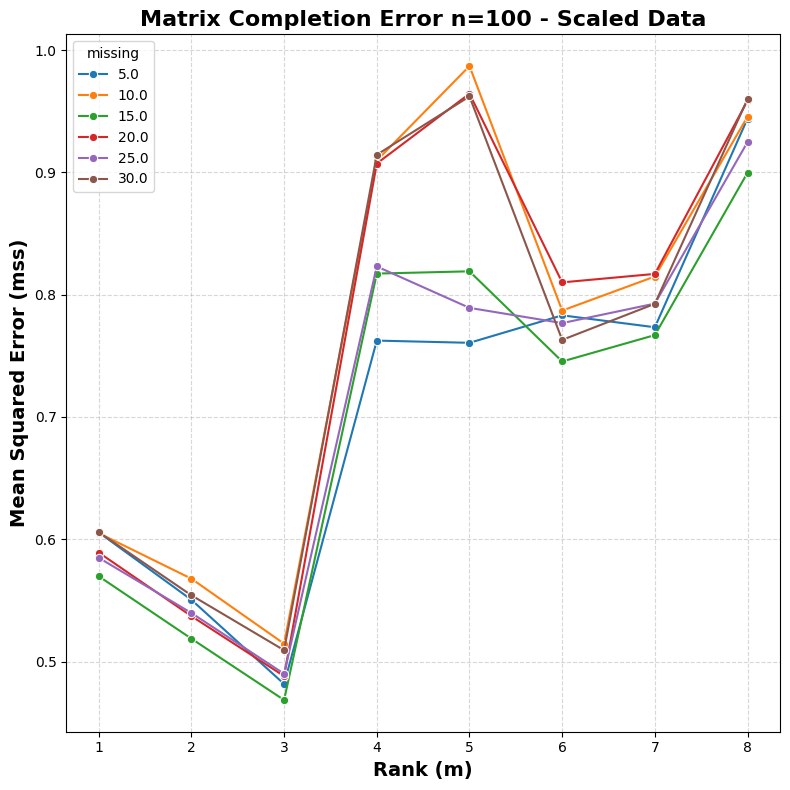

In [50]:
# Plot results
palette = sns.color_palette("tab10", n_colors=results_agg['missing'].nunique())
plt.figure(figsize=(8, 8))
sns.lineplot(
    data=results_agg, 
    x='m', 
    y='mss', 
    hue='missing', 
    marker='o',
    palette=palette
)
plt.xlabel('Rank (m)', **axis_args)
plt.ylabel('Mean Squared Error (mss)', **axis_args)
plt.title('Matrix Completion Error n=100 - Scaled Data', **title_args)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

After scaling the data, the results change significantly. We observe better performance in the lowest mean squared score ('mss') when using rank 'm'=3. In contrast, without scaling, the best performance was achieved with 'm'=1. This highlights how a single feature with a disproportionately large scale can overshadow others and dominate the matrix completion process.

By scaling the data before matrix completion, we allow the model to effectively utilize higher ranks ('m'), which capture more structure in the data and improve the algorithm's ability to optimize the reconstruction task.

---

### Question 12

Our previous function 'matrix_completion()' can take a different argument to implement Algorithm 12.1 by using the PCA method. Let's test it.

In [51]:
# Ensure 'boston' is an array
boston_array = np.asarray(boston_scaled)

In [52]:
# Create a function to perform low rank approximation
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:, :M] * D[None, :M]
    return L.dot(V[:M])

In [53]:
# Create a function to perform PCA approximation
def pca_approximation(X, M=1):
    pca = PCA()
    pca.fit(X)
    scores = pca.transform(X) # L
    components = pca.components_ # V
    return scores[:, :M].dot(components[:M])

In [54]:
# Check the first results from low rank
low_rank(boston_array)[0]

array([-0.49514554,  0.51892235, -0.69185013,  0.00693261, -0.67581474,
        0.42950368, -0.6226371 ,  0.62401701, -0.62311881, -0.66791834,
       -0.43604464, -0.64712209,  0.55280943])

In [55]:
# Check the first results from PCA
pca_approximation(boston_array)[0]

array([-0.49514554,  0.51892235, -0.69185013,  0.00693261, -0.67581474,
        0.42950368, -0.6226371 ,  0.62401701, -0.62311881, -0.66791834,
       -0.43604464, -0.64712209,  0.55280943])

We've seen that low rank approximation provides the same results as PCA when applied to data that has been standardized to have mean zero and standard deviation one.

Therefore, we can expect the same outcome when applying Algorithm 12.1 for matrix completion using the PCA method instead of low rank.

In [56]:
# Ensure 'boston' is an array
boston_array = np.asarray(boston_scaled)

# Initialize a dataframe to store the results
columns = ['repetition', 'missing', 'm', 'mss']
results = pd.DataFrame(columns=columns)

# Perform the experiment 20x
np.random.seed (1)
for n in range(1, 21):

    # Create missing data from 5% to 30%
    for i in range(5, 31, 5):            
        # Number of observations to omit
        n_omit = int(len(boston_array) * (i/100))

        # Select rows and columns
        row_idx = np.random.choice(
            np.arange(boston_array.shape[0]),
            n_omit,
            replace=False
        )
        col_idx = np.random.choice(
            np.arange(boston_array.shape[1]),
            n_omit,
            replace=True
        )

        # Creat a dataframe with missing values
        Xna = boston_array.copy()
        Xna = np.asarray(Xna)
        Xna[row_idx, col_idx] = np.nan
        missing = np.isnan(Xna)

        # Perform matrix completion over a range of Ms
        for m in range(1, 9):
            Xhat = matrix_completion(
                X=Xna, 
                M=m,
                rank_func=pca_approximation,
                verbose=False
            )
            mss = np.mean(((boston_array - Xhat)[missing])**2)

            # Update dataframe
            results.loc[len(results)] = (n, i, m, mss)

In [57]:
# Group results by their average
columns = ['missing', 'm']
results_agg = results.groupby(columns).agg({
    'mss': 'mean'
}).reset_index()

# Sort & show results
results_agg.sort_values(by='mss', ascending=True)

,missing,m,mss
2,5.0,3.0,0.430357
26,20.0,3.0,0.493394
18,15.0,3.0,0.499435
34,25.0,3.0,0.512152
1,5.0,2.0,0.516928
42,30.0,3.0,0.517551
25,20.0,2.0,0.530934
10,10.0,3.0,0.536005
17,15.0,2.0,0.546744
41,30.0,2.0,0.562417


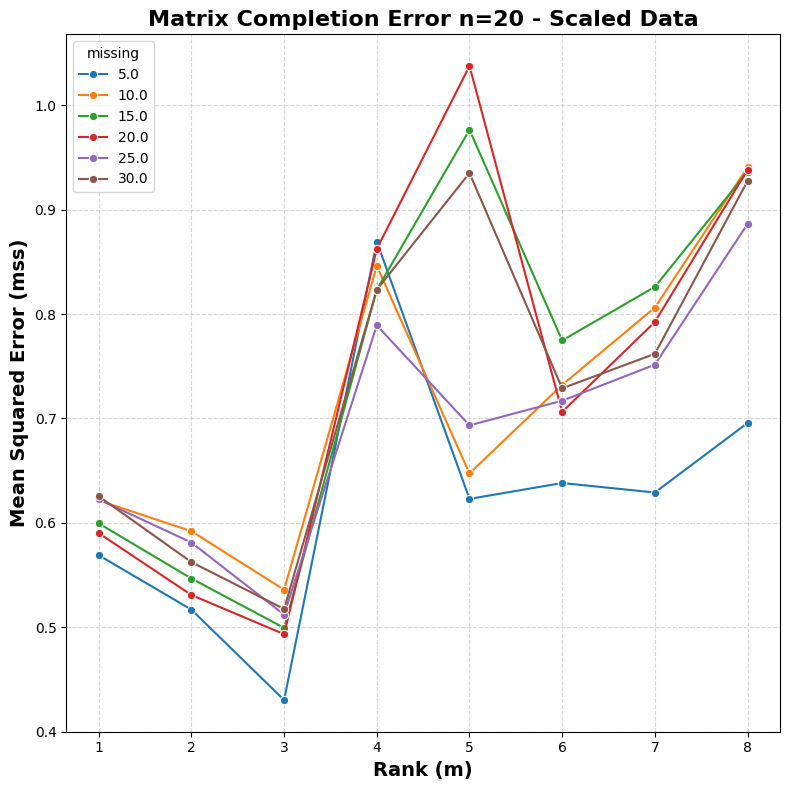

In [58]:
# Plot results
palette = sns.color_palette("tab10", n_colors=results_agg['missing'].nunique())
plt.figure(figsize=(8, 8))
sns.lineplot(
    data=results_agg, 
    x='m', 
    y='mss', 
    hue='missing', 
    marker='o',
    palette=palette
)
plt.xlabel('Rank (m)', **axis_args)
plt.ylabel('Mean Squared Error (mss)', **axis_args)
plt.title('Matrix Completion Error n=20 - Scaled Data', **title_args)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

As expected, using the PCA method provides identical results to the low rank approximation.

---

### Question 13

#### 13a)

In [3]:
# Load dataset
genes_data = pd.read_csv('data/Ch12Ex13.csv', header=None)
genes_data.head()

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-0.961933,0.441803,-0.975005,1.417504,0.818815,0.316294,-0.024967,-0.063966,0.031497,-0.350311,...,-0.509591,-0.216725,-0.055506,-0.484449,-0.521581,1.949135,1.324335,0.468147,1.061100,1.655970
1,-0.292526,-1.139267,0.195837,-1.281121,-0.251439,2.511997,-0.922206,0.059543,-1.409645,-0.656712,...,1.700708,0.007290,0.099062,0.563853,-0.257275,-0.581781,-0.169887,-0.542304,0.312939,-1.284377
2,0.258788,-0.972845,0.588486,-0.800258,-1.820398,-2.058924,-0.064764,1.592124,-0.173117,-0.121087,...,-0.615472,0.009999,0.945810,-0.318521,-0.117889,0.621366,-0.070764,0.401682,-0.016227,-0.526553
3,-1.152132,-2.213168,-0.861525,0.630925,0.951772,-1.165724,-0.391559,1.063619,-0.350009,-1.489058,...,-0.284277,0.198946,-0.091833,0.349628,-0.298910,1.513696,0.671185,0.010855,-1.043689,1.625275
4,0.195783,0.593306,0.282992,0.247147,1.978668,-0.871018,-0.989715,-1.032253,-1.109654,-0.385142,...,-0.692998,-0.845707,-0.177497,-0.166491,1.483155,-1.687946,-0.141430,0.200778,-0.675942,2.220611


In [72]:
# Check dataset dimensions
genes_data.shape

(1000, 40)

#### 13b)

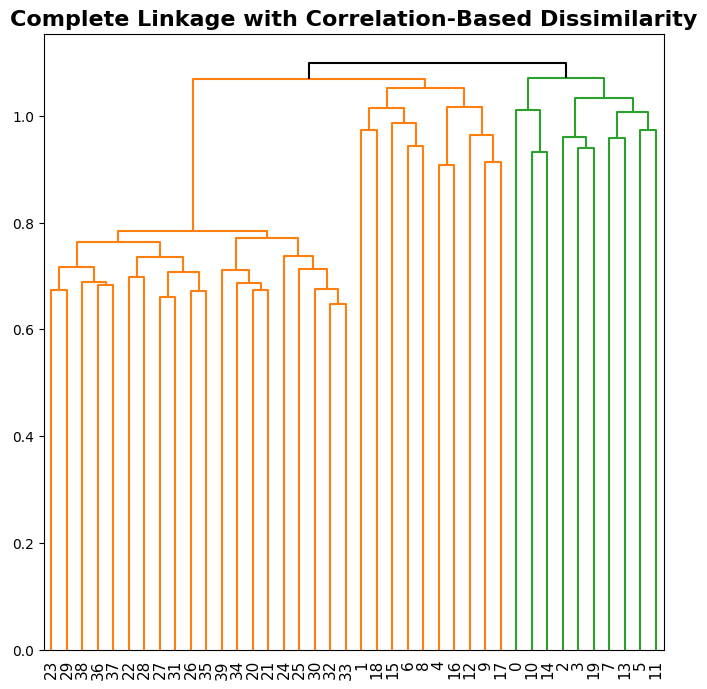

In [ ]:
# Linkages
linkage_list = ['complete', 'single', 'average']

# Using correlation as dissimilarity matrix for clustering
HClust = AgglomerativeClustering
corD = 1 - np.corrcoef(genes_data.T)
hc_cor = HClust(
    linkage='complete',
    distance_threshold=0,
    n_clusters=None,
    metric='precomputed'
)
hc_cor.fit(corD)
linkage_cor = compute_linkage(hc_cor)

# Find & set 2 clusters
threshold_2clusters = linkage_cor[-1, 2] #last distance

# Plot
cargs = {
    'color_threshold': threshold_2clusters,
    'above_threshold_color': 'black'
}
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_cor, 
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=11,
    **cargs
)
ax.set_title(
    "Complete Linkage with Correlation-Based Dissimilarity",
    **title_args
);

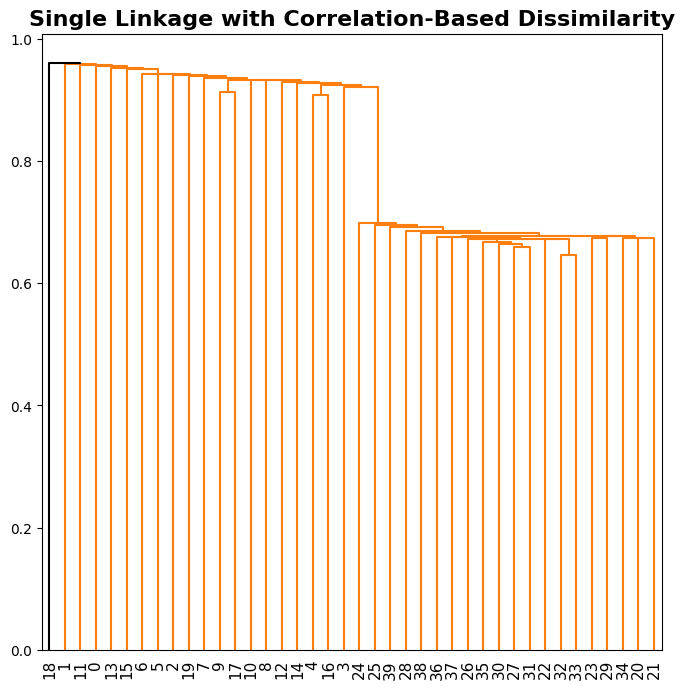

In [37]:
# Using correlation as dissimilarity matrix for clustering
HClust = AgglomerativeClustering
corD = 1 - np.corrcoef(genes_data.T)
hc_cor = HClust(
    linkage='single',
    distance_threshold=0,
    n_clusters=None,
    metric='precomputed'
)
hc_cor.fit(corD)
linkage_cor = compute_linkage(hc_cor)

# Find & set 2 clusters
threshold_2clusters = linkage_cor[-1, 2] #last distance

# Plot
cargs = {
    'color_threshold': threshold_2clusters,
    'above_threshold_color': 'black'
}
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_cor, 
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=11,
    **cargs
)
ax.set_title(
    "Single Linkage with Correlation-Based Dissimilarity",
    **title_args
);

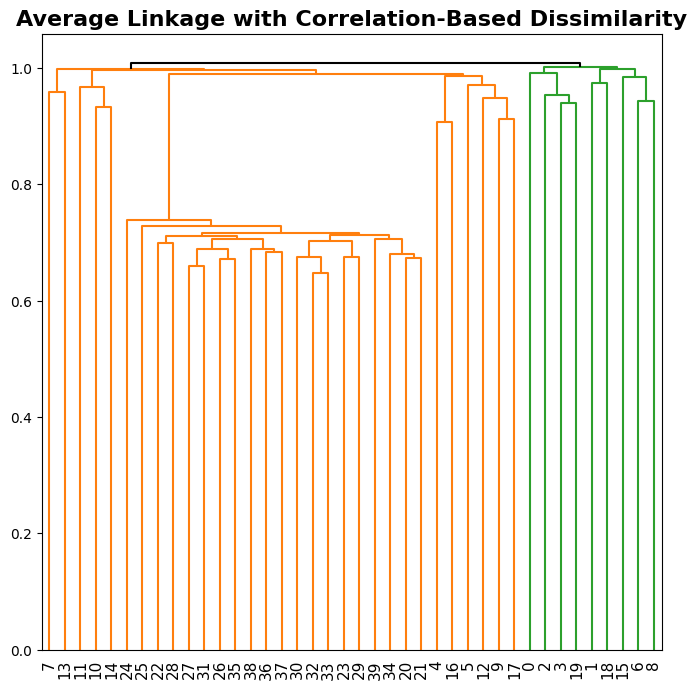

In [38]:
# Using correlation as dissimilarity matrix for clustering
HClust = AgglomerativeClustering
corD = 1 - np.corrcoef(genes_data.T)
hc_cor = HClust(
    linkage='average',
    distance_threshold=0,
    n_clusters=None,
    metric='precomputed'
)
hc_cor.fit(corD)
linkage_cor = compute_linkage(hc_cor)

# Find & set 2 clusters
threshold_2clusters = linkage_cor[-1, 2] #last distance

# Plot
cargs = {
    'color_threshold': threshold_2clusters,
    'above_threshold_color': 'black'
}
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_cor, 
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=11,
    **cargs
)
ax.set_title(
    "Average Linkage with Correlation-Based Dissimilarity",
    **title_args
);

It is possible to cluster the genes into different groups. However, as demonstrated above, this approach fails when we attempt to force the data into just 2 clusters. Intuitively, one might expect to separate the genes into 2 categoris: healthy and diseased. But the structure of the hierarchical clustering does not support such simple split.

Notably, the complete linkage method appears to outperform the others. When clustering into four groups, we observe that 3 clusters predominantly contain healthy patients, while 1 cluster captures the majority of diseased patients.

In summary, effective separation into 2 categories (healthy vs diseased) is only possible by clustering into more than 2 groups and then interpreting those clusters accordingly. The results are sensitive to the choice of linkage method.

In the example below, the orange cluster contains most of the diseased samples, while the remaining clusters primarily contain healthy individuals.

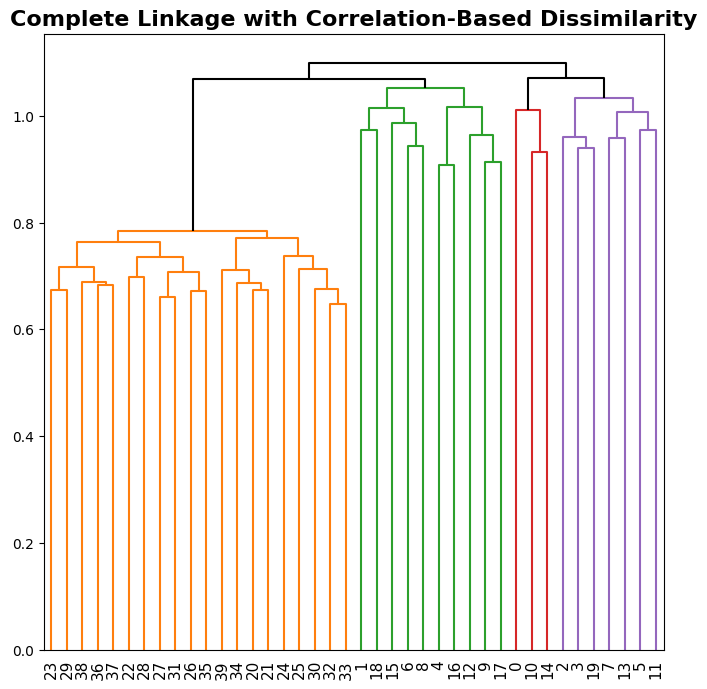

In [39]:
# Linkages
linkage_list = ['complete', 'single', 'average']

# Using correlation as dissimilarity matrix for clustering
HClust = AgglomerativeClustering
corD = 1 - np.corrcoef(genes_data.T)
hc_cor = HClust(
    linkage='complete',
    distance_threshold=0,
    n_clusters=None,
    metric='precomputed'
)
hc_cor.fit(corD)
linkage_cor = compute_linkage(hc_cor)

# Find & set 2 clusters
threshold_2clusters = linkage_cor[-3, 2] #last distance

# Plot
cargs = {
    'color_threshold': threshold_2clusters,
    'above_threshold_color': 'black'
}
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_cor, 
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=11,
    **cargs
)
ax.set_title(
    "Complete Linkage with Correlation-Based Dissimilarity",
    **title_args
);

#### 13c)

Our first clustering attempt provides valuable insight into which genes differ the most between the 2 groups. When clustering into only 2 groups, we observe that a subset of genes from healthy individuals stands out.

This subseet of genes is likely the most distinguishable between the groups. Please refer to the green cluster below, which highlights the genes with the most divergence.

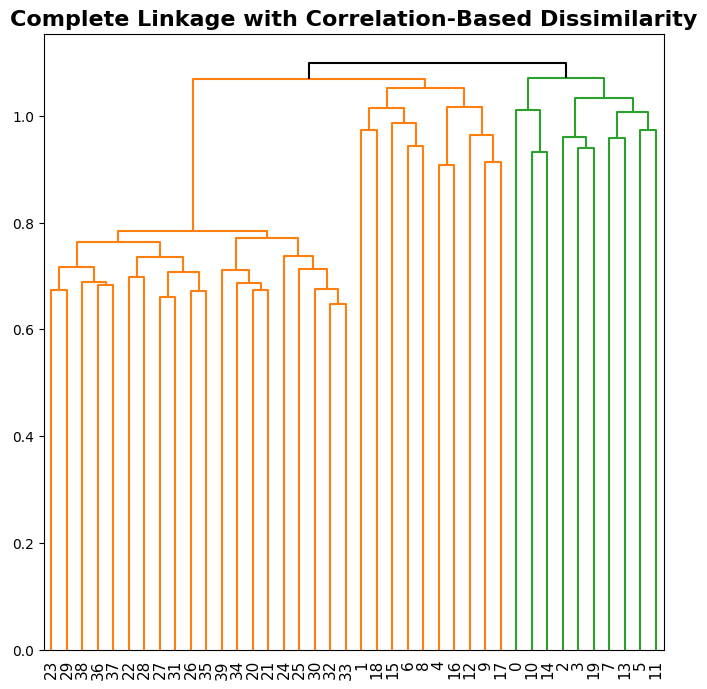

In [41]:
# Linkages
linkage_list = ['complete', 'single', 'average']

# Using correlation as dissimilarity matrix for clustering
HClust = AgglomerativeClustering
corD = 1 - np.corrcoef(genes_data.T)
hc_cor = HClust(
    linkage='complete',
    distance_threshold=0,
    n_clusters=None,
    metric='precomputed'
)
hc_cor.fit(corD)
linkage_cor = compute_linkage(hc_cor)

# Find & set 2 clusters
threshold_2clusters = linkage_cor[-1, 2] #last distance

# Plot
cargs = {
    'color_threshold': threshold_2clusters,
    'above_threshold_color': 'black'
}
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(
    linkage_cor, 
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=11,
    **cargs
)
ax.set_title(
    "Complete Linkage with Correlation-Based Dissimilarity",
    **title_args
);